# Exercise 9: Effect of Non-Random Noise in Input Features

**Authors**:
- Ariful Islam Riane : 3981886
- Pedro Fernandez Tonso : 3983781
- Group Number : 19

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.io import arff
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

## 1. Load and Prepare Data

In [2]:
def load_and_prepare_data(file_path):
    ar, _ = arff.loadarff(file_path)
    df = pd.DataFrame(ar).dropna()
    for col in df.select_dtypes(include='object').columns:
        df[col] = df[col].map(lambda x: x.decode() if isinstance(x, bytes) else x)
    return df

file_path = Path('../databank/00_raw/uci-large/credit-a.arff')
if not file_path.exists():
    file_path = Path('dq-lab-1/databank/00_raw/uci-large/credit-a.arff')

data = load_and_prepare_data(file_path)
base_cols = pd.get_dummies(data.drop('class', axis=1)).drop(
    [c for c in pd.get_dummies(data.drop('class', axis=1)).columns if c.endswith('_?')],
    axis=1
).columns

## 2. Evaluation and Noise Injection

In [3]:
def evaluate(df, base_columns, random_state=100):
    X = pd.get_dummies(df.drop('class', axis=1)).reindex(columns=base_columns, fill_value=0)
    y = df['class']
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, train_size=0.7, test_size=0.3, random_state=random_state
    )
    clf = GaussianNB().fit(X_train, y_train)
    return accuracy_score(y_test, clf.predict(X_test))

def inject_noise(df, selector_col, selector_val, target_col, noise_level, rng):
    if selector_col == target_col:
        raise ValueError('Selector and target attributes cannot be identical.')
    df_out = df.copy()
    mask = (
        (df_out[selector_col] == selector_val)
        if selector_col is not None
        else np.ones(len(df_out), dtype=bool)
    )
    target_idx = df_out.index[mask].to_numpy()
    n_corrupt = int(len(target_idx) * noise_level)
    if n_corrupt > 0:
        chosen_idx = rng.choice(target_idx, size=n_corrupt, replace=False)
        col = df_out[target_col]
        if col.dtype in ('object', 'str', 'string'):
            df_out.loc[chosen_idx, target_col] = rng.choice(col.dropna().unique(), size=n_corrupt)
        else:
            df_out.loc[chosen_idx, target_col] = rng.uniform(col.min(), col.max(), size=n_corrupt)
    return df_out, len(target_idx), n_corrupt

def run_experiment(df, selector_col, selector_val, target_col, noise_levels=None, base_columns=None, n_seeds=5):
    if selector_col == target_col:
        raise ValueError('Selector and target attributes cannot be identical.')
    if noise_levels is None:
        noise_levels = [round(0.05 * i, 2) for i in range(21)]
    
    target_indices = df.index[df[selector_col] == selector_val].to_numpy()
    n_target = len(target_indices)
    n_total = len(df)
    baseline_acc = evaluate(df, base_columns)
    
    records = []
    for p in noise_levels:
        k = int(n_target * p)
        accs_nr, accs_rand = [], []
        for s in range(n_seeds):
            rng = np.random.default_rng(s)
            df_nr, _, _ = inject_noise(df, selector_col, selector_val, target_col, p, rng)
            accs_nr.append(evaluate(df_nr, base_columns))
            
            df_rand, _, _ = inject_noise(df, None, None, target_col, k / n_total if n_total > 0 else 0, rng)
            accs_rand.append(evaluate(df_rand, base_columns))
            
        records.append({
            'noise_level': p,
            'corrupted_count': k,
            'acc_non_random': float(np.mean(accs_nr)),
            'acc_random_proportional': float(np.mean(accs_rand))
        })
    return pd.DataFrame(records), baseline_acc, n_target, n_total

def plot_noise_comparison(df_res, baseline_acc, selector_col, selector_val, target_col, n_target, n_total):
    plt.figure(figsize=(8, 5))
    p = df_res['noise_level']
    plt.plot(p, df_res['acc_non_random'], marker='o', linewidth=2, label=f'Non-Random ({selector_col}={selector_val})')
    plt.plot(p, df_res['acc_random_proportional'], marker='s', linewidth=1.5, linestyle='--', label='Proportional Random (Matched Count k)')
    plt.axhline(baseline_acc, color='red', linestyle='-.', alpha=0.7, label=f'Baseline (0% noise): {baseline_acc:.4f}')
    plt.title(f'Non-Random vs Proportional Random Noise: Target={target_col} | Selector={selector_col}={selector_val} ({n_target}/{n_total} rows)', fontsize=12)
    plt.xlabel('Noise Level (Proportion of Target Subpopulation Corrupted)', fontsize=11)
    plt.ylabel('Accuracy', fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{int(round(y*100))}%"))
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()

In [4]:
def subgroup_breakdown(df, selector_col, selector_val, target_col,
                       base_columns, noise_levels=None, n_seeds=5):
    """Per-noise-level test accuracy split into the corrupted subgroup (selector == value)
    and the spared subgroup, for non-random vs count-matched random noise."""
    if noise_levels is None:
        noise_levels = [round(0.1 * i, 1) for i in range(11)]
    n_target = int((df[selector_col] == selector_val).sum())
    n_total = len(df)

    def eval_split(d):
        X = pd.get_dummies(d.drop('class', axis=1)).reindex(columns=base_columns, fill_value=0)
        y = d['class']
        X_tr, X_te, y_tr, y_te = train_test_split(X, y, train_size=0.7, test_size=0.3, random_state=100)
        pred = GaussianNB().fit(X_tr, y_tr).predict(X_te)
        inside = (d.loc[X_te.index, selector_col] == selector_val).to_numpy()
        return (accuracy_score(y_te, pred),
                accuracy_score(y_te[inside], pred[inside]),
                accuracy_score(y_te[~inside], pred[~inside]))

    rows = []
    for p in noise_levels:
        k = int(n_target * p)
        acc = {key: [] for key in ('all_nr', 'all_rand', 'in_nr', 'in_rand', 'out_nr', 'out_rand')}
        for s in range(n_seeds):
            rng = np.random.default_rng(s)
            df_nr, _, _ = inject_noise(df, selector_col, selector_val, target_col, p, rng)
            df_rand, _, _ = inject_noise(df, None, None, target_col, k / n_total, rng)
            a_nr = eval_split(df_nr)
            a_rd = eval_split(df_rand)
            for j, tag in enumerate(('all', 'in', 'out')):
                acc[f'{tag}_nr'].append(a_nr[j])
                acc[f'{tag}_rand'].append(a_rd[j])
        rows.append({'noise_level': p, 'k': k, **{key: float(np.mean(v)) for key, v in acc.items()}})
    return pd.DataFrame(rows)


def plot_subgroup_breakdown(bd, selector_col, selector_val, target_col, save_path=None):
    p = bd['noise_level']
    plt.figure(figsize=(8, 5))
    plt.plot(p, bd['in_nr'],  'o-',  color='#1f77b4', label=f'corrupted subgroup ({selector_col}={selector_val}) - non-random')
    plt.plot(p, bd['in_rand'], 's--', color='#1f77b4', alpha=0.6, label=f'corrupted subgroup - random')
    plt.plot(p, bd['out_nr'],  'o-',  color='#2ca02c', label='spared subgroup - non-random')
    plt.plot(p, bd['out_rand'], 's--', color='#2ca02c', alpha=0.6, label='spared subgroup - random')
    plt.title(f'Where the damage lands: {target_col} corrupted within {selector_col}={selector_val}', fontsize=12)
    plt.xlabel('Noise level (fraction of the corrupted subgroup / matched count k)', fontsize=11)
    plt.ylabel('Test accuracy', fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{int(round(y * 100))}%"))
    plt.legend(loc='best', fontsize=9)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=110, bbox_inches='tight')
    plt.show()


## 3. Experiment: Non-Random Noise in Numerical Feature (A15 Income conditioned on A9='t')

In [5]:
df_num, base_acc_num, n_target_num, n_total_num = run_experiment(
    data, 'A9', 't', 'A15', base_columns=base_cols
)
print(f"Baseline Accuracy: {base_acc_num:.4f} | Target Group Size: {n_target_num}/{n_total_num} ({n_target_num/n_total_num*100:.1f}%)")
df_num.iloc[::2]

Baseline Accuracy: 0.8250 | Target Group Size: 352/666 (52.9%)


,noise_level,corrupted_count,acc_non_random,acc_random_proportional
0,0.0,0,0.825,0.825
2,0.1,35,0.829,0.822
4,0.2,70,0.791,0.798
6,0.3,105,0.776,0.789
8,0.4,140,0.757,0.783
10,0.5,176,0.757,0.758
12,0.6,211,0.776,0.744
14,0.7,246,0.773,0.742
16,0.8,281,0.802,0.737
18,0.9,316,0.788,0.732


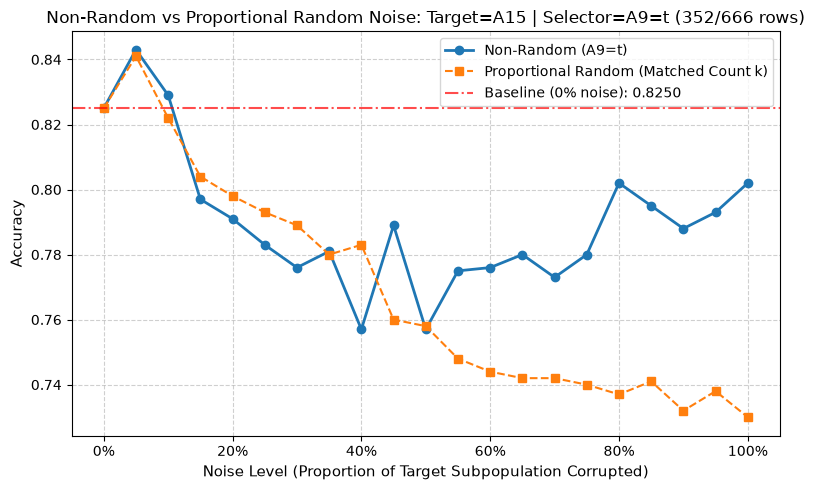

In [6]:
plot_noise_comparison(df_num, base_acc_num, 'A9', 't', 'A15', n_target_num, n_total_num)

### Where does the damage land? (A15 within A9='t')

The single accuracy curve above hides *which* rows get misclassified. Here we split the
test set into the **corrupted subgroup** (`A9='t'`, whose income we are destroying) and the
**spared subgroup** (`A9='f'`, untouched), and compare non-random vs count-matched random
noise on each.


 noise_level   k  all_nr  all_rand  in_nr  in_rand  out_nr  out_rand
         0.0   0   0.825     0.825  0.743    0.743   0.923     0.923
         0.1  35   0.829     0.822  0.743    0.750   0.932     0.908
         0.2  70   0.791     0.798  0.686    0.708   0.916     0.905
         0.3 105   0.776     0.789  0.659    0.688   0.916     0.910
         0.4 140   0.757     0.783  0.628    0.675   0.912     0.912
         0.5 176   0.757     0.758  0.626    0.629   0.914     0.912
         0.6 211   0.776     0.744  0.657    0.604   0.919     0.912
         0.7 246   0.773     0.742  0.648    0.600   0.923     0.912
         0.8 281   0.802     0.737  0.701    0.591   0.923     0.912
         0.9 316   0.788     0.732  0.675    0.583   0.923     0.910
         1.0 352   0.802     0.730  0.701    0.578   0.923     0.912


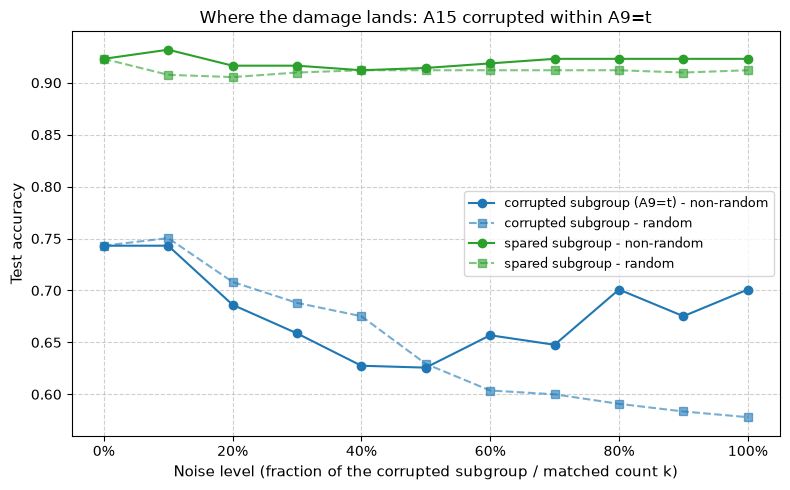

In [7]:
bd_num = subgroup_breakdown(data, 'A9', 't', 'A15', base_cols)
print(bd_num.round(3).to_string(index=False))
plot_subgroup_breakdown(bd_num, 'A9', 't', 'A15', save_path='images/ex09_fig3.png')


## 4. Experiment: Non-Random Noise in Categorical Feature (A9 Prior Default conditioned on A10='f')

In [8]:
df_cat, base_acc_cat, n_target_cat, n_total_cat = run_experiment(
    data, 'A10', 'f', 'A9', base_columns=base_cols
)
print(f"Baseline Accuracy: {base_acc_cat:.4f} | Target Group Size: {n_target_cat}/{n_total_cat} ({n_target_cat/n_total_cat*100:.1f}%)")
df_cat.iloc[::2]

Baseline Accuracy: 0.8250 | Target Group Size: 376/666 (56.5%)


,noise_level,corrupted_count,acc_non_random,acc_random_proportional
0,0.0,0,0.825,0.825
2,0.1,37,0.824,0.819
4,0.2,75,0.823,0.820
6,0.3,112,0.824,0.807
8,0.4,150,0.811,0.804
10,0.5,188,0.809,0.798
12,0.6,225,0.808,0.799
14,0.7,263,0.806,0.796
16,0.8,300,0.800,0.788
18,0.9,338,0.807,0.789


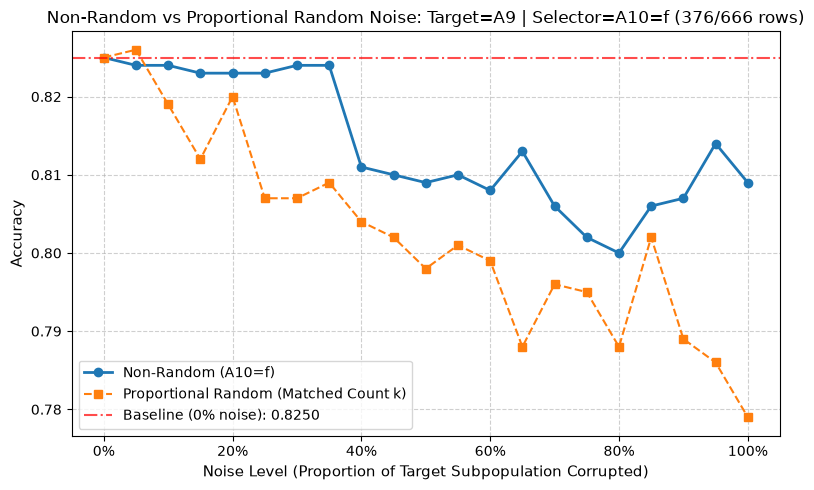

In [9]:
plot_noise_comparison(df_cat, base_acc_cat, 'A10', 'f', 'A9', n_target_cat, n_total_cat)

### Where does the damage land? (A9 within A10='f')


 noise_level   k  all_nr  all_rand  in_nr  in_rand  out_nr  out_rand
         0.0   0   0.825     0.825  0.806    0.806   0.845     0.845
         0.1  37   0.824     0.819  0.804    0.802   0.845     0.837
         0.2  75   0.823     0.820  0.802    0.802   0.845     0.839
         0.3 112   0.824     0.807  0.808    0.802   0.841     0.812
         0.4 150   0.811     0.804  0.794    0.798   0.829     0.810
         0.5 188   0.809     0.798  0.796    0.802   0.823     0.794
         0.6 225   0.808     0.799  0.794    0.796   0.823     0.802
         0.7 263   0.806     0.796  0.788    0.806   0.825     0.786
         0.8 300   0.800     0.788  0.777    0.781   0.825     0.796
         0.9 338   0.807     0.789  0.790    0.798   0.825     0.779
         1.0 376   0.809     0.779  0.794    0.783   0.825     0.775


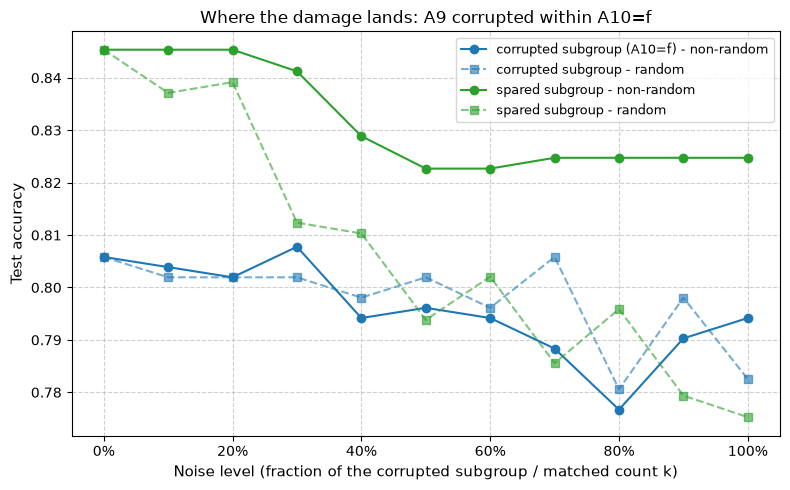

In [10]:
bd_cat = subgroup_breakdown(data, 'A10', 'f', 'A9', base_cols)
print(bd_cat.round(3).to_string(index=False))
plot_subgroup_breakdown(bd_cat, 'A10', 'f', 'A9', save_path='images/ex09_fig4.png')


## Takeaways

Non-random noise corrupts the target feature only inside a subgroup fixed by the selector
attribute; the complementary subgroup is left clean. We compare it against **proportional
random** noise that corrupts the *same number of rows* `k`, drawn from anywhere. Both hit
train and test (the split happens after injection). Curves are averaged over 5 seeds, and
the tables above split test accuracy into the corrupted vs the spared subgroup.

**What we saw**

- **Non-random noise degrades less than count-matched random noise, especially at high
  noise.** For `A15` the non-random curve dips to ~0.77 around 40-50% and then *recovers*
  to ~0.80 at 100%, while proportional-random keeps sinking to ~0.73.
- **The two cases reach that result by different routes:**
  - `A15` within `A9='t'` (numerical): the spared subgroup (`A9='f'`) sits at ~0.92
    whichever way noise is added - all the difference is in the corrupted subgroup, where
    non-random ends at ~0.70 (U-shaped) vs random ~0.58 (steady decline).
  - `A9` within `A10='f'` (categorical): here the corrupted subgroup is resilient *both*
    ways (~0.79); the difference is in the spared subgroup - random noise leaks into
    `A10='t'` rows and drags them from ~0.85 to ~0.78, while non-random leaves them
    untouched.

**Why** (this was the opposite of what we expected - we thought conditional noise would be
worse because it wipes out *all* information about the target given the selector value)

- Confining the corruption to one identifiable subgroup always leaves the model a clean
  place to stand: either the spared subgroup is genuinely untouched, or the corrupted
  subgroup's damage is *consistent between train and test* so the model learns to lean on
  the other features instead.
- In the `A15`/`A9='t'` case the second effect dominates. Non-random noise corrupts income
  the same way in train and test for every `A9='t'` row, so the model gets no usable income
  signal there and falls back on `A9='t'` itself, which favours "approved" (~74% predicted
  `+`, close to the clean 79%). Random noise corrupts only ~half the subgroup, so the model
  half-learns the real "low income -> reject" rule and then misapplies it to test rows whose
  income is a random draw (predicted `+` collapses to ~56%).
- We checked the consistency point directly: corrupting `A15` for `A9='t'` in **training
  only** drops accuracy far more (0.70 overall, 0.52 on the subgroup) than corrupting train
  **and** test together (0.80 / 0.70).

**Practical implication**

- Where the errors fall matters as much as how many there are. A structured error aligned
  with a feature the model can see is something the model routes around; the same volume
  scattered unpredictably keeps the model trusting a feature that has gone unreliable.
- Aggregate "% corrupted" hides this, and it hides that a targeted error can look benign in
  overall accuracy while systematically hurting one subgroup. The direction of the effect
  also depends on which subgroup is targeted - `A9='t'` is the harder group but has a
  strong fallback (`A9` itself).
